In [4]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install emoji

Note: you may need to restart the kernel to use updated packages.


In [6]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [56]:
%pip install pip setuptools wheel
%pip install spacy

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [7]:
import matplotlib.pyplot as plt

In [8]:
import sys
print(sys.executable)
print(sys.version)

/Users/jgamez/Documents/MCD/Ingenieria_Caracteristicas/whatsapp/proyecto_git/ing_caracteristicas_whatsapp/.venv/bin/python
3.10.21 (main, Sep  1 2026, 14:06:09) [Clang 22.1.3 ]


In [9]:
from pathlib import Path

import pandas as pd

In [10]:
import emoji

In [11]:
import spacy
from collections import Counter

nlp = spacy.load("es_core_news_sm")

In [36]:
import plotly.express as px

In [12]:



# Paths
PROJ_ROOT = Path.cwd().parent
DATA_PATH = PROJ_ROOT / "data" / "processed" / "whatsapp_messages.csv"

# Load processed dataset
df = pd.read_csv(
    DATA_PATH,
    parse_dates=["datetime"],
)

df.head()

,message_id,datetime,date,time,year,month,day,day_of_week,hour,sender,content_type,is_forwarded,has_url,url,has_caption,message_length,word_count,content,text
0,1,2025-09-28 12:19:00,2025-09-28,12:19:00,2025,9,28,Sunday,12,Alakazam,text,False,False,NaN,False,15,2,<Media omitted>,<Media omitted>
1,2,2025-09-28 12:19:00,2025-09-28,12:19:00,2025,9,28,Sunday,12,Alakazam,text,False,False,NaN,False,104,18,Saludos amigos hice este grupo para que saquen...,Saludos amigos hice este grupo para que saquen...
2,3,2025-09-28 12:25:00,2025-09-28,12:25:00,2025,9,28,Sunday,12,Vaporeon,text,False,False,NaN,False,15,2,<Media omitted>,<Media omitted>
3,4,2025-09-28 12:31:00,2025-09-28,12:31:00,2025,9,28,Sunday,12,Bulbasaur,text,False,False,NaN,False,11,1,Interesante,Interesante
4,5,2025-09-28 12:32:00,2025-09-28,12:32:00,2025,9,28,Sunday,12,Bulbasaur,text,False,False,NaN,False,15,2,<Media omitted>,<Media omitted>


In [37]:
# Messages per participant as a DataFrame
messages_per_person = (
    df.groupby("sender")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="messages")
)

messages_per_person.head(1)

# Gráfica
fig = px.bar(
    messages_per_person,
    x="sender",
    y="messages",
    title="Messages per user",
    labels={
        "sender": "User",
        "messages": "Number of messages"
    }
)

fig.show()

¿Cual es la frecuencia promedio de palabras por mensaje de texto de cada usuario?

In [14]:
# Filter only text messages
text_messages = df[df["content_type"] == "text"]

# Average words per text message by user
avg_words_per_user = (
    text_messages
    .groupby("sender")["word_count"]
    .mean()
    .sort_values(ascending=False)
    .reset_index(name="avg_words_per_message")
)

avg_words_per_user.iloc[0]

sender                    Snorlax
avg_words_per_message    5.545455
Name: 0, dtype: object

Usuario que envía más palabras

In [15]:
words_per_user = (
    df.groupby("sender")["word_count"]
    .sum()
    .sort_values(ascending=False)
)

words_per_user

top_words_user = words_per_user.idxmax()
top_words = words_per_user.max()

print(f"{top_words_user} es quien más palabras envía: {top_words} palabras.")

Alakazam es quien más palabras envía: 22677 palabras.


¿Quién manda más emojis?

In [16]:
def count_emojis(text):
    if not isinstance(text, str):
        return 0

    return len(emoji.emoji_list(text))


df["emoji_count"] = df["content"].apply(count_emojis)

emojis_per_user = (
    df.groupby("sender")["emoji_count"]
    .sum()
    .sort_values(ascending=False)
)

emojis_per_user
top_emoji_user = emojis_per_user.idxmax()
top_emojis = emojis_per_user.max()

print(f"{top_emoji_user} es quien más emojis envía: {top_emojis} emojis.")

Alakazam es quien más emojis envía: 197 emojis.


Quién Envía más stickers

In [ ]:
stickers_per_user = (
    df[df["content_type"] == "sticker"]
    .groupby("sender")
    .size()
    .sort_values(ascending=False)
)

stickers_per_user

top_sticker_user = stickers_per_user.idxmax()
top_stickers = stickers_per_user.max()

print(
    f"{top_sticker_user} es quien más stickers envía: "
    f"{top_stickers} stickers."
)


Series([], dtype: int64)

Análisis semanal

In [17]:
days_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

messages_by_day = (
    df["day_of_week"]
    .value_counts()
    .reindex(days_order)
    .reset_index()
)

messages_by_day.columns = ["day_of_week", "messages"]

messages_by_day

,day_of_week,messages
0,Monday,1494
1,Tuesday,3080
2,Wednesday,2580
3,Thursday,1562
4,Friday,1738
5,Saturday,3444
6,Sunday,2155


In [18]:
most_active_day = messages_by_day.loc[
    messages_by_day["messages"].idxmax()
]

least_active_day = messages_by_day.loc[
    messages_by_day["messages"].idxmin()
]

print(
    f"Día con más mensajes: "
    f"{most_active_day['day_of_week']} "
    f"({most_active_day['messages']} mensajes)"
)

print(
    f"Día con menos mensajes: "
    f"{least_active_day['day_of_week']} "
    f"({least_active_day['messages']} mensajes)"
)

Día con más mensajes: Saturday (3444 mensajes)
Día con menos mensajes: Monday (1494 mensajes)


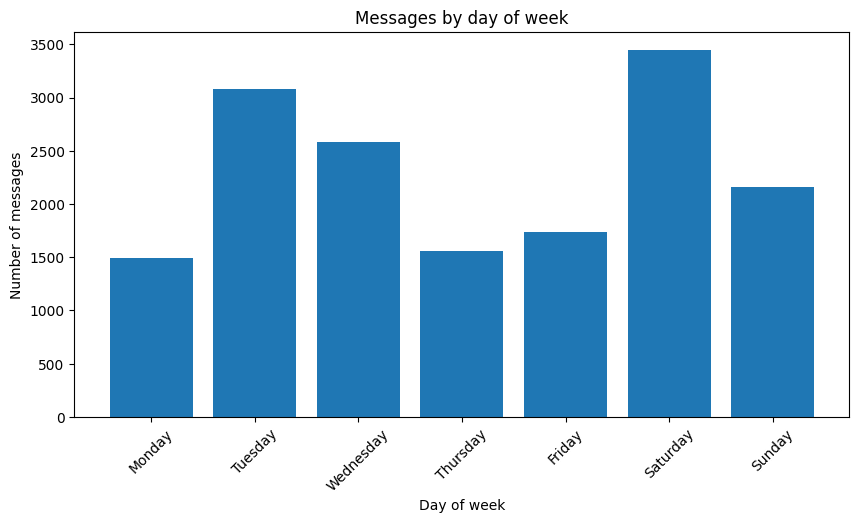

In [19]:
plt.figure(figsize=(10, 5))

plt.bar(
    messages_by_day["day_of_week"],
    messages_by_day["messages"],
)

plt.xlabel("Day of week")
plt.ylabel("Number of messages")
plt.title("Messages by day of week")
plt.xticks(rotation=45)

plt.show()

In [20]:
messages_by_hour = (
    df.groupby("hour")
    .size()
    .reindex(range(24), fill_value=0)
    .reset_index(name="messages")
)

messages_by_hour

,hour,messages
0,0,36
1,1,15
2,2,10
3,3,4
4,4,1
5,5,5
6,6,16
7,7,129
8,8,434
9,9,683


In [21]:
most_active_hour = messages_by_hour.loc[
    messages_by_hour["messages"].idxmax()
]

least_active_hour = messages_by_hour.loc[
    messages_by_hour["messages"].idxmin()
]

print(
    f"Hora con más mensajes: "
    f"{int(most_active_hour['hour']):02d}:00 "
    f"({most_active_hour['messages']} mensajes)"
)

print(
    f"Hora con menos mensajes: "
    f"{int(least_active_hour['hour']):02d}:00 "
    f"({least_active_hour['messages']} mensajes)"
)

Hora con más mensajes: 13:00 (1853 mensajes)
Hora con menos mensajes: 04:00 (1 mensajes)


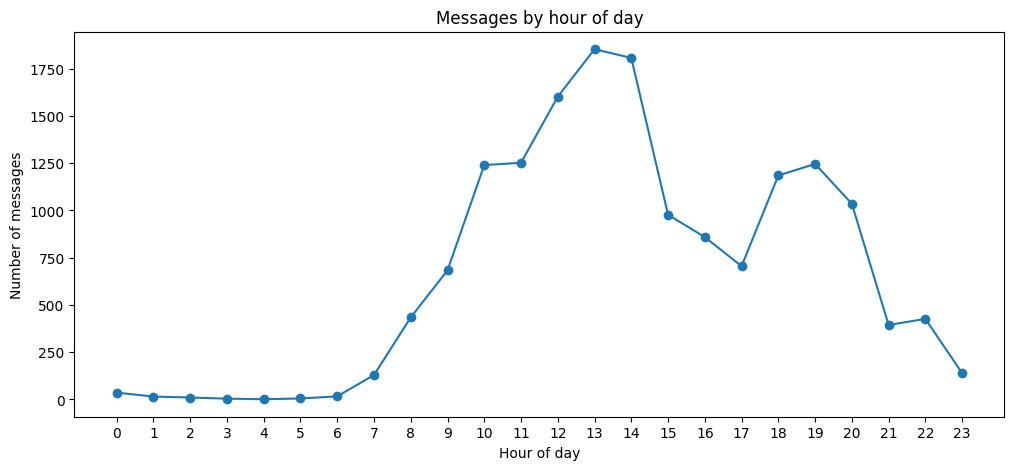

In [22]:
plt.figure(figsize=(12, 5))

plt.plot(
    messages_by_hour["hour"],
    messages_by_hour["messages"],
    marker="o",
)

plt.xlabel("Hour of day")
plt.ylabel("Number of messages")
plt.title("Messages by hour of day")
plt.xticks(range(24))

plt.show()

In [39]:
fig = px.line(
    messages_by_hour,
    x="hour",
    y="messages",
    markers=True,
    title="Messages by hour of day",
    labels={
        "hour": "Hour",
        "messages": "Number of messages"
    }
)

fig.update_xaxes(dtick=1)

fig.show()

In [38]:
messages_per_date = (
    df.groupby(["date", "day_of_week"])
    .size()
    .reset_index(name="messages")
)

avg_messages_by_day = (
    messages_per_date
    .groupby("day_of_week")["messages"]
    .mean()
    .reindex(days_order)
    .reset_index()
)

avg_messages_by_day

fig = px.bar(
    avg_messages_by_day,
    x="day_of_week",
    y="messages",
    title="Average messages by day of week",
    labels={
        "day_of_week": "Day of week",
        "messages": "Average number of messages"
    }
)

fig.show()

Spacy

In [24]:

text_messages = df[
    (df["content_type"] == "text")
    & df["text"].notna()
].copy()

Palabras más usadas en general

In [28]:


def extract_all_words(text):
    doc = nlp(text)

    return [
        token.text.lower()
        for token in doc
        if token.is_alpha
    ]


all_words = []

for text in text_messages["text"]:
    all_words.extend(extract_all_words(text))


word_counts = Counter(all_words)

most_common_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["word", "count"]
)

most_common_words

,word,count
0,media,3633
1,omitted,3626
2,el,2276
3,que,1912
4,de,1744
5,a,1582
6,la,1310
7,no,1267
8,se,978
9,y,851


In [30]:
CUSTOM_STOP_WORDS = {
    "message",
    "omitted",
    "this"
}

In [40]:
def extract_relevant_words(text):
    doc = nlp(text)

    return [
        token.lemma_.lower()
        for token in doc
        if token.is_alpha
        and not token.is_stop
        and token.lemma_.lower() not in CUSTOM_STOP_WORDS
    ]


relevant_words = []

for text in text_messages["text"]:
    relevant_words.extend(extract_relevant_words(text))


relevant_word_counts = Counter(relevant_words)

most_common_without_stopwords = pd.DataFrame(
    relevant_word_counts.most_common(20),
    columns=["word", "count"]
)

most_common_without_stopwords

fig = px.bar(
    most_common_without_stopwords,
    x="count",
    y="word",
    orientation="h",
    title="Most common words (excluding stop words)",
    labels={
        "word": "Word",
        "count": "Frequency"
    }
)

fig.show()

Palabras más usadas por usuario

In [32]:
def most_common_words_by_user(group, n=10):
    words = []

    for text in group["text"].dropna():
        words.extend(extract_relevant_words(text))

    return Counter(words).most_common(n)

rows = []

for sender, group in text_messages.groupby("sender"):
    common_words = most_common_words_by_user(group, n=10)

    for rank, (word, count) in enumerate(common_words, start=1):
        rows.append({
            "sender": sender,
            "rank": rank,
            "word": word,
            "count": count,
        })

top_words_by_user = pd.DataFrame(rows)

top_words_by_user

,sender,rank,word,count
0,Alakazam,1,medio,1115
1,Alakazam,2,partido,138
2,Alakazam,3,gol,120
3,Alakazam,4,ganar,93
4,Alakazam,5,we,91
...,...,...,...,...
188,Vaporeon,6,ganar,32
189,Vaporeon,7,alv,31
190,Vaporeon,8,lpm,29
191,Vaporeon,9,venir,29


Miembro en particular

In [34]:
top_words_by_user[
    top_words_by_user["sender"] == "Vaporeon"
]

,sender,rank,word,count
183,Vaporeon,1,medio,941
184,Vaporeon,2,gol,51
185,Vaporeon,3,alb,49
186,Vaporeon,4,pa,41
187,Vaporeon,5,partido,36
188,Vaporeon,6,ganar,32
189,Vaporeon,7,alv,31
190,Vaporeon,8,lpm,29
191,Vaporeon,9,venir,29
192,Vaporeon,10,uff,28


In [35]:
top_word_per_user = (
    top_words_by_user[
        top_words_by_user["rank"] == 1
    ]
    .reset_index(drop=True)
)

top_word_per_user

,sender,rank,word,count
0,Alakazam,1,medio,1115
1,Bulbasaur,1,medio,48
2,Charizard,1,medio,167
3,Ditto,1,medio,1
4,Dragonite,1,medio,221
5,Eevee,1,medio,55
6,Flareon,1,medio,89
7,Gengar,1,medio,8
8,Gyarados,1,medio,27
9,Jigglypuff,1,we,3


¿Cuáles son los adjetivos más utilizados?

In [41]:
def extract_adjectives(text):
    doc = nlp(text)

    return [
        token.lemma_.lower()
        for token in doc
        if token.pos_ == "ADJ"
        and token.is_alpha
    ]


all_adjectives = []

for text in text_messages["text"]:
    all_adjectives.extend(extract_adjectives(text))

adjective_counts = Counter(all_adjectives)

most_common_adjectives = pd.DataFrame(
    adjective_counts.most_common(20),
    columns=["adjective", "count"]
)

most_common_adjectives

,adjective,count
0,primero,74
1,mejor,69
2,bueno,68
3,nuevo,67
4,buen,60
5,penal,58
6,grande,52
7,puro,50
8,segundo,47
9,vergo,42


In [42]:
top_adjectives = (
    most_common_adjectives
    .head(20)
    .sort_values("count")
)

fig = px.bar(
    top_adjectives,
    x="count",
    y="adjective",
    orientation="h",
    title="Most common adjectives",
    labels={
        "adjective": "Adjective",
        "count": "Frequency"
    }
)

fig.show()